# Modelling the Efficiency of a Tungsten-Filament Bulb through Black-Body Radiation and Human Visual Sensitivity.
**Arthur Luong, Department of Physics, Queen Mary, University of London.**


In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as const
from scipy.integrate import quad

### Abstract

In this Jupyter Notebook, I applied the Planck Radiation Law to model the efficiency of a black-body radiator in emitting visible light. By plotting an efficiency against temperature graph, I found that a black-body radiator emits visible light most efficiently at $6939K$, with an efficiency of $(55.54 \pm 6.167 \times 10^{-13})\%$. Then, using CIE data for the sensitivity of the human eye at each wavelength, I saw that the human eye perceives the visible light of a black-body radiator most efficiently at $6631K$ with an efficiency of $(13.97 \pm 3.191 \times 10^{-4})\%$.

# Introduction

Historically, bulbs were used to illuminate dark spaces, with the first bulbs invented by Thomas Edison featuring a carbon filament that could last between 600 and 1000 hours [1]. After that, the invention of the tungsten filament light bulb by William Coolidge led to an increase in its lifespan to more than 1000 hours, depending on how the bulb was used [2]. However, the problem with these bulbs is that they convert a significant portion of the electrical energy used to heat the filament into heat rather than visible light.

The Planck Radiation Law describes the intensity of a black-body radiator as a function of the wavelength it emits and its temperature. It was derived from the Rayleigh-Jeans Law, which shared the same premise but failed to account for shorter wavelengths (i.e., ultraviolet), where the intensity would diverge to infinity. This divergence was known as the ultraviolet catastrophe [3].

With this, the intensity of a tungsten bulb at each wavelength can be determined. However, as important as the object emitting the light is, the same can be said for the object absorbing this light, aka our eyes. The sensitivity of our eyes is said to be modelled by the Spectral Luminous Efficiency Function [4], which is a function that, for each wavelength of light, the eye will perceive only a percentage of that light.

This report will cover the method for getting the radiative efficiency of a black-body radiator emitting visible light, the method for weighting this efficiency, taking into account the eye's sensitivity, and the conclusions drawn from these results.

# Method

As mentioned in the introduction, I can model efficiency by first defining the Planck Radiation Law:

\begin{equation}
I(\lambda, T) = \frac{2hc^2}{\lambda^5} \cdot \frac{1}{\exp(hc/(\lambda k_B T)) - 1}
\end{equation}

where $I$ is the power radiated per unit wavelength, $\lambda$ is the wavelength emitted, $h$ is Planck's constant, $c$ is the speed of light, $k_B$ is the Boltzmann constant, and $T$ is the temperature radiated.

As visible light is what I need, by integrating the Planck Radiation Law in terms of wavelength in the region of visible light, the useful power of a black-body radiator can be found:

\begin{equation}
\int_{\lambda_1}^{\lambda_2} I(\lambda) \, d\lambda.
\end{equation}

To find the total power, the law is integrated from $0$ to $\infty$ as the wavelength can be any real positive number:

\begin{equation}
\int_{0}^{\infty} I(\lambda) \, d\lambda.
\end{equation}

To simplify this, an arbitrary $x$ substitution is made to make the integral easier:

\begin{equation}
x = \frac{hc}{\lambda k_B T} \longrightarrow I = \frac{2hc^2}{\lambda^5} \cdot \frac{1}{\exp(hc/(\lambda k_B T)) - 1} \leadsto I = C\frac{x^3}{\exp(x) - 1}
\end{equation}

Where $C$ is a prefactor that gets cancelled out soon. Therefore, the integrals transform into:

\begin{equation}
C\int_{hc/\lambda_2 k_B T}^{hc/\lambda_1 k_B T} \frac{x^3}{\exp(x) - 1} \, dx \quad \text{and} \quad C\int_{0}^{\infty} \frac{x^3}{\exp(x) - 1} \, dx.
\end{equation}


The integrand for these integrals is defined as a Python function below:

In [2]:
def integrand(x):
    return x**3/(np.exp(x)-1)

For the integral for the whole electromagnetic spectrum, the following identity can be used:

\begin{equation}
C\int_{0}^{\infty} \frac{x^3}{\exp(x) - 1} \, dx = C\frac{\pi^4}{15}.
\end{equation}

By using the standard definition for efficiency: 

\begin{equation}
\eta = \frac{\text{Useful Power}}{\text{Total Power}},
\end{equation}

The efficiency of a blackbody radiator radiating a certain region of wavelengths can be found:

\begin{equation}
\eta = \frac{C\int_{hc/\lambda_2 k_B T}^{hc/\lambda_1 k_B T} \frac{x^3}{\exp(x) - 1} \, dx}{C\frac{\pi^4}{15}} = \frac{15}{\pi^4}\int_{hc/\lambda_2 k_B T}^{hc/\lambda_1 k_B T} \frac{x^3}{\exp(x) - 1} \, dx.
\end{equation}

This integral will be calculated numerically below using the scipy.integrate.quad function. This function uses the Gaussian Quadrature method to calculate the integral. This method will provide high accuracy, as the integral will be calculated by adjusting its step size according to the local behavior of the integrand, as opposed to other methods, such as the trapezoidal or Simpson method, which have a fixed step size. This will return an accurate answer along with its uncertainty.

In [3]:
def efficiency(T):
    upper_x_limit = (const.h*const.c)/(lambda1*const.k*T)
    lower_x_limit = (const.h*const.c)/(lambda2*const.k*T)
    
    integral,error = quad(integrand, lower_x_limit, upper_x_limit, limit=200)
    efficiency = (15/(np.pi)**4)*integral*100
    efficiency_error = (15/(np.pi)**4)*error*100  #Changing the efficiencies to percentages.
    return efficiency, efficiency_error

As the visible light region is being evaluated, the bounds for it will be used, and the efficiencies and their errors will be evaluated from $2000K$ to $20000K$ and stored in a list to be plotted in the results section of the report:

In [4]:
lambda1 = 360e-9 
lambda2 = 830e-9

temperatures = np.linspace(2000, 20000, 1000) 
efficiencies = []
efficiency_errors = []
for T in temperatures:
    efficiency_element, efficiency_error_element = efficiency(T)
    efficiencies.append(efficiency_element) 
    efficiency_errors.append(efficiency_error_element)

To model the eye's efficiency, data from the International Commission on Illumination (CIE) will be utilised [5]. I chose photopic vision as it is suitable for bright environments, which is ideal for general use. This data includes each integer wavelength in the visible light region of the electromagnetic spectrum, along with the eye's response to it in terms of sensitivity. As the data file has two columns, I split each row into an element of a list, where each element contains another list with the wavelength and its corresponding eye sensitivity.

In [5]:
f = open('CIE_sle_photopic.csv', 'r')
csvreader = csv.reader(f)
rows = list(csvreader)
f.close()

These wavelengths and sensitivities are then stored in lists for later use.

In [6]:
wavelengths = []
wavelengths_in_e = []
efficiencies_for_eye = []
for row in rows:
    wavelengths.append(float(row[0])*1e-9) 
    wavelengths_in_e.append(float(row[0]))
    efficiencies_for_eye.append(float(row[1]))

The function below uses linear interpolation to estimate the efficiency of a wavelength that isn't part of the dataset, because the CIE data contains wavelengths at $1nm$ intervals. Therefore, by using:

\begin{equation}
\frac{s - s_1}{s_2 - s_1} = \frac{\lambda - \lambda_1}{\lambda_2 - \lambda_1}\longrightarrow s = s_1 + (\frac{\lambda - \lambda_1}{\lambda_2 - \lambda_1})(s_2 - s_1),
\end{equation}

Where $\lambda$ is the wavelength given, $\lambda_1$ and $\lambda_2$ are the nearest wavelengths surrounding the given wavelength, $s_1$ and $s_2$ are the sensitivities of the surrounding wavelengths, and $s$ is the calculated sensitivity at the given wavelength, the efficiency at any real wavelength can be estimated.

In [7]:
def efficiency_of_eye_given_wavelength(wavelength):
    for i in range(len(wavelengths) - 1):
        if wavelengths[i] <= wavelength <= wavelengths[i + 1]:
            w1, w2 = wavelengths[i], wavelengths[i + 1]
            s1, s2 = efficiencies_for_eye[i], efficiencies_for_eye[i+1]
            interpolate_fraction = (wavelength - w1)/(w2 - w1)
            return s1 + interpolate_fraction * (s2 - s1)

The same efficiency calculation method is used, with the Planck spectrum being multiplied by the eye's sensitivity before the numerical integration, shown in the function below. This alteration would give the percentage of power that is perceived as visible light by the human eye.

In [8]:
def newintegrand(x, T):
    wavelength = (const.h*const.c)/(x*const.k*T)
    return x**3/(np.exp(x)-1)*efficiency_of_eye_given_wavelength(wavelength)
    
def eye_efficiency(T):
    upper_x_limit = (const.h*const.c)/(lambda1*const.k*T)
    lower_x_limit = (const.h*const.c)/(lambda2*const.k*T)
    
    integral, error = quad(newintegrand, lower_x_limit, upper_x_limit, limit=200, args=(T,))
    efficiency = (15/(np.pi)**4)*integral*100
    efficiency_error = (15/(np.pi)**4)*error*100
    return efficiency, efficiency_error

As before, the efficiencies and their respective errors are calculated with the same range of temperatures and stored in a list to be plotted in the results.

In [9]:
eye_efficiencies_for_planck = [] #Takes some time to finish.
eye_efficiency_errors = []
for T in temperatures:
    eye_eff, eye_eff_error = eye_efficiency(T)
    eye_efficiencies_for_planck.append(eye_eff)
    eye_efficiency_errors.append(eye_eff_error)

/tmp/ipykernel_440/2262007893.py:9: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral, error = quad(newintegrand, lower_x_limit, upper_x_limit, limit=200, args=(T,))


# Results

When plotting the efficiency of a black-body radiator against its temperature, I get:

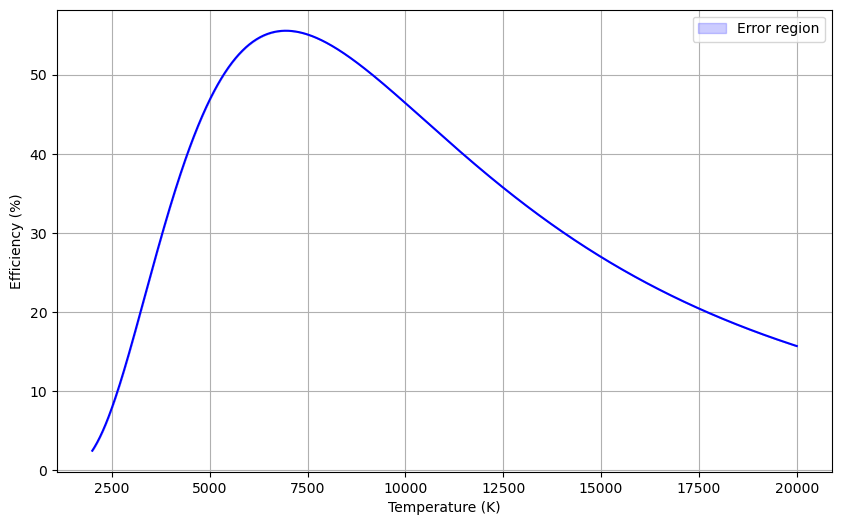

In [10]:
upper_errors = []
lower_errors = []
for i in range(len(efficiencies)):    
    upper_errors.append(efficiencies[i] + efficiency_errors[i])
    lower_errors.append(efficiencies[i] - efficiency_errors[i])

plt.figure(figsize=(10,6))
plt.plot(temperatures, efficiencies, color='b') 
plt.fill_between(temperatures, lower_errors, upper_errors, alpha=0.2, color='b', label='Error region')
plt.xlabel("Temperature (K)")
plt.ylabel("Efficiency (%)")
plt.legend()
plt.grid()

###### Figure 1: Efficiency against Temperature plot of a black-body radiator before error exaggeration.

Since the error region is minuscule, the following plot will exaggerate it for viewing:

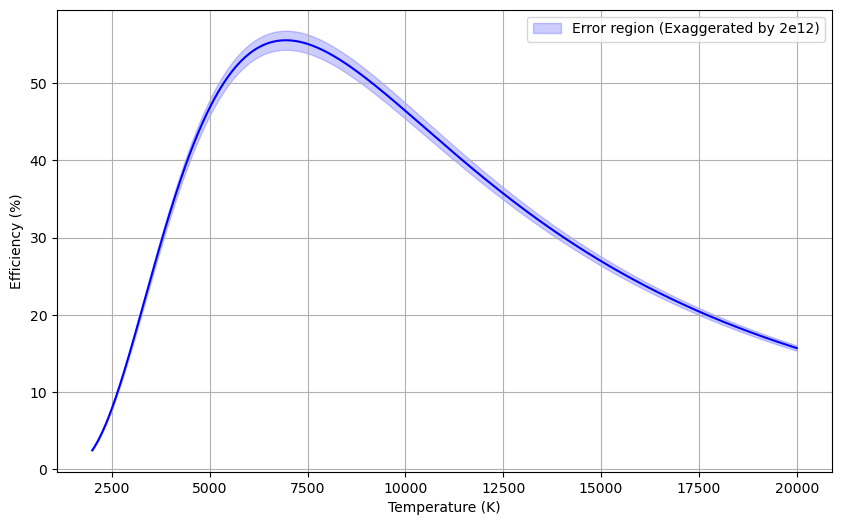

In [11]:
upper_errors_exaggerated = []
lower_errors_exaggerated = []
for i in range(len(efficiencies)):    
    upper_errors_exaggerated.append(efficiencies[i] + efficiency_errors[i]*2e12)
    lower_errors_exaggerated.append(efficiencies[i] - efficiency_errors[i]*2e12)

plt.figure(figsize=(10,6))
plt.plot(temperatures, efficiencies, color='b')
plt.xlabel("Temperature (K)")
plt.ylabel("Efficiency (%)")
plt.fill_between(temperatures, lower_errors_exaggerated, upper_errors_exaggerated, alpha=0.2, color='b', label='Error region (Exaggerated by 2e12)')
plt.legend()
plt.grid()

###### Figure 2: Efficiency against Temperature plot of a black-body radiator after error exaggeration.

By using the standard max() function and the np.argmax() function, the maximum efficiency of a black-body radiator emitting visible light, and the temperature it has to be to do so can be found:

In [12]:
maximum_efficiency = max(efficiencies) 
maximum_efficiency_index = np.argmax(efficiencies)
maximum_efficiency_error = efficiency_errors[maximum_efficiency_index]
temperature_at_max_eff = temperatures[maximum_efficiency_index]

print("The maximum efficiency on the graph is: (" ,maximum_efficiency,"±",maximum_efficiency_error,")%")
print("Therefore, the temperature to get this efficiency is:" ,temperature_at_max_eff,"K")

The maximum efficiency on the graph is: ( 55.543404843058816 ± 6.166556692284034e-13 )%
Therefore, the temperature to get this efficiency is: 6936.936936936937 K


For discussion purposes, a graph to show the eye's sensitivity for each wavelength is plotted:

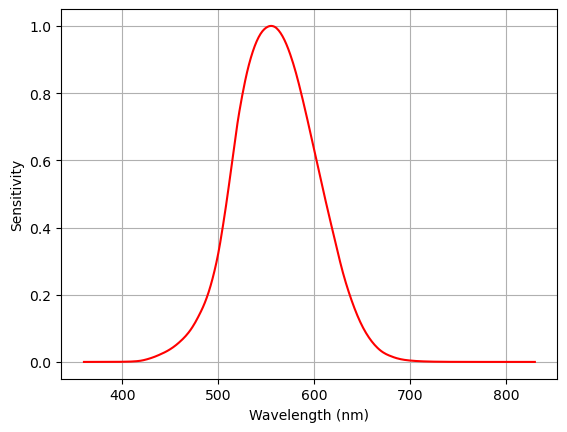

In [13]:
plt.plot(wavelengths_in_e, efficiencies_for_eye, 'r')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Sensitivity")
plt.grid()

###### Figure 3: Sensitivity against Wavelength plot for the eye.

Next, the plot for the efficiency of the eye is added along with the plot for the efficiency of the black-body radiator against temperature:

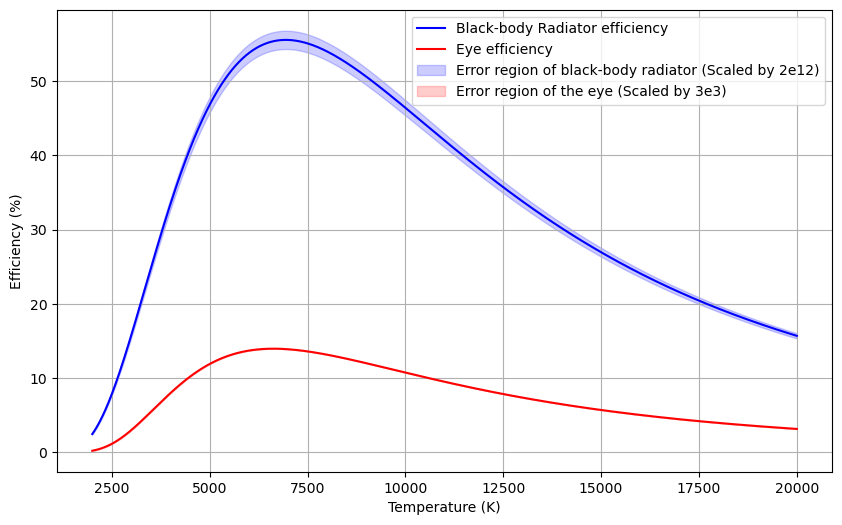

In [14]:
upper_eye_efficiencies_errors = []
lower_eye_efficiencies_errors = []
for i in range(len(efficiencies)):     
    upper_eye_efficiencies_errors.append(eye_efficiencies_for_planck[i] + eye_efficiency_errors[i])
    lower_eye_efficiencies_errors.append(eye_efficiencies_for_planck[i] - eye_efficiency_errors[i])

plt.figure(figsize=(10,6))
plt.plot(temperatures, efficiencies, label = "Black-body Radiator efficiency", color = 'b')
plt.plot(temperatures, eye_efficiencies_for_planck, label = "Eye efficiency", color = 'r')
plt.fill_between(temperatures, lower_errors_exaggerated, upper_errors_exaggerated, alpha=0.2, color='b', label='Error region of black-body radiator (Scaled by 2e12)')
plt.fill_between(temperatures, lower_eye_efficiencies_errors, upper_eye_efficiencies_errors, alpha=0.2, color='r', label='Error region of the eye (Scaled by 3e3)')
plt.xlabel("Temperature (K)")
plt.ylabel("Efficiency (%)")
plt.grid()
plt.legend()

###### Figure 4: Efficiency against Temperature plot of a black-body radiator and the eye before error exaggeration.

Like before, the error region for the eye is too small, so the following plot will exaggerate it:

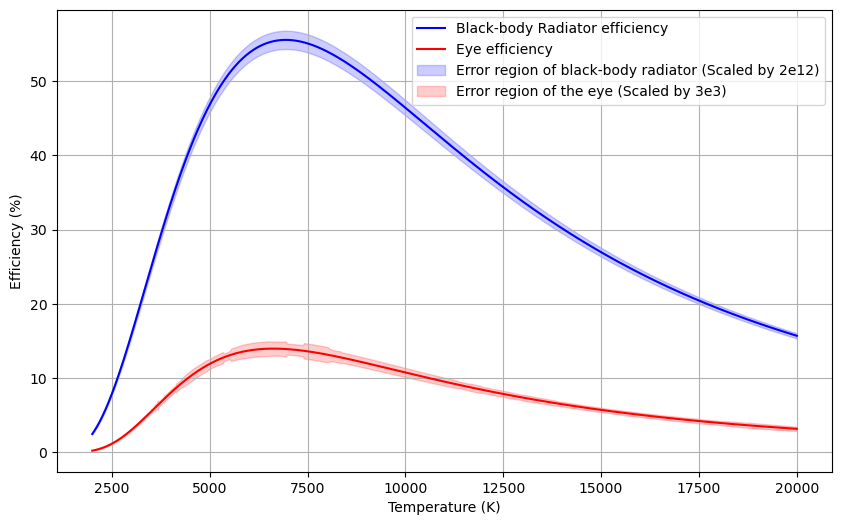

In [15]:
upper_eye_efficiencies_errors_exaggerated = []
lower_eye_efficiencies_errors_exaggerated = []
for i in range(len(efficiencies)):     
    upper_eye_efficiencies_errors_exaggerated.append(eye_efficiencies_for_planck[i] + eye_efficiency_errors[i]*3e3)
    lower_eye_efficiencies_errors_exaggerated.append(eye_efficiencies_for_planck[i] - eye_efficiency_errors[i]*3e3)

plt.figure(figsize=(10,6))
plt.plot(temperatures, efficiencies, label = "Black-body Radiator efficiency", color = 'b')
plt.plot(temperatures, eye_efficiencies_for_planck, label = "Eye efficiency", color = 'r')
plt.fill_between(temperatures, lower_errors_exaggerated, upper_errors_exaggerated, alpha=0.2, color='b', label='Error region of black-body radiator (Scaled by 2e12)')
plt.fill_between(temperatures, lower_eye_efficiencies_errors_exaggerated, upper_eye_efficiencies_errors_exaggerated, alpha=0.2, color='r', label='Error region of the eye (Scaled by 3e3)')
plt.xlabel("Temperature (K)")
plt.ylabel("Efficiency (%)")
plt.grid()
plt.legend()

###### Figure 5: Efficiency against Temperature plot of a black-body radiator and the eye after error exaggeration.

By using the standard max() function and the np.argmax() function again, the maximum efficiency of the eye perceiving visible light from a black-body radiator can be found.

In [16]:
print("The maximum efficiency for the eye is: (" ,max(eye_efficiencies_for_planck),"±",eye_efficiency_errors[np.argmax(eye_efficiencies_for_planck)],")%")
print("Therefore, the temperature to get this efficiency is:" ,temperatures[np.argmax(eye_efficiencies_for_planck)],"K")

The maximum efficiency for the eye is: ( 13.971943099265479 ± 0.0003191227986097711 )%
Therefore, the temperature to get this efficiency is: 6630.630630630631 K


# Discussion
From Figure 2, there is a sharp rise in efficiency at lower temperatures as more energy is available, therefore, increasing the power in the visible light region. At $T = 6937K$, it peaks to $\eta_B = (55.54 \pm 6.167 \times 10^{-13})\%$ and then begins to fall. This fall is because the energy is now being directed into the ultraviolet region of the radiator; hence, there is less power available for visible light, and thus, this represents the thermodynamic upper limit of a black-body radiator when analysing the amount of visible light it emits.

Moreover, with such a high $T$ value, it also introduces real-world limitations as the melting point of tungsten is $3687K$ [6], which is far below the thermodynamic upper limit. This limit means that a standard tungsten filament bulb would never reach the thermodynamic efficiency limit due to material limitations, as the filament would evaporate if the temperature were to increase. Furthermore, the average operating temperature of a tungsten filament bulb is around $2773K$ [7]. In a real-world setting, only around $10\%$ of the radiation from a standard tungsten filament bulb is visible light, which explains the intrinsic inefficiency and demonstrates that a tungsten bulb is not ideal for lighting.

Beyond the material limitations, human vision further reduces the overall output. By weighing the Planck Spectrum with the eye's sensitivity, this results in Figure 5. The eye perceives less light than what the black-body radiator emits, as the curve for the eye's absorption efficiency is always lower than the black-body radiator efficiency. This curve peaks at $\eta_e = (13.97 \pm 3.191 \times 10^{-4})\%$ at $T = 6631K$, meaning the eye perceives only around a quarter of the peak radiative efficiency. It is also important to note the locations of the peaks for the two curves, as the curve for the eye is shifted slightly to the left, as shown by the difference in temperatures for peak efficiency. This difference is because at higher temperatures, black-body radiators emit short-wavelength radiation. The eye does not perceive shorter wavelengths well, as shown in Figure 3, where there is a rapid decline in the eye's ability to perceive shorter wavelengths; hence, longer wavelengths are seen. Because of this, the eye is better at perceiving a temperature that is less than ideal for a black-body radiator.

# Conclusion

By integrating the Planck Radiation Law and calculating efficiency for a black-body radiator and for when the eye absorbs this light, I showed that there are three limitations when viewing a black-body radiator. First, the thermodynamic upper limit, demonstrated with the peak efficiency of a black-body radiator being $\eta_B = (55.54 \pm 6.167 \times 10^{-13})\%$, meaning only  around $55.54\%$ of radiated power falls within the visible light region, with the remainder being turned into other electromagnetic radiation. 

Second, there are the material limitations. For an average tungsten filament bulb, its operating temperature is almost half the temperature needed for peak efficiency, so the average bulb loses a substantial amount of efficiency. Moreover, even if the temperature increases, the melting point of tungsten would prevent the bulb from working, as the filament has either melted or evaporated, indicating that a tungsten filament bulb is not an ideal light source.

Third, the sensitivity of the eye, shown with an efficiency of $\eta_e = (13.97 \pm 3.191 \times 10^{-4})\%$, showing that the eye perceives almost four times less visible light when viewing a black-body radiator. Furthermore, because the eye does not perceive short-wavelength radiation, it does not accurately perceive the black-body radiator radiating at peak efficiency, as indicated by the difference in temperatures at which both peak efficiencies occur.

One improvement to this study could be to also explore the efficiency of a black-body radiator for different regions of the electromagnetic spectrum. Although a tungsten filament bulb is less ideal for lighting, it could be suitable for heating, i.e, exploring the infrared region, as many incandescent bulbs convert their input power into heat, as shown in the report. This also assumes that the tungsten filament bulb is a perfect black-body radiator, which is not true in the real world. A fix could be to weight the Planck Spectrum, as I did with eye sensitivity, but instead using the emissivity of the tungsten filament. A real-world fix to the inefficiency of the bulb is to use LEDs instead, since although incandescent bulbs use heat to glow, LEDs use de-excited electrons, which release photons to light up; hence, they are limited by quantum mechanics rather than thermodynamics, so an efficiency model for an LED could be plotted for comparison. Another improvement to this study could be to analyse the different types of vision models, such as scotopic for darkness, and mesopic for dimly lit environments, as not all the time environments are well-lit enough for a photopic model. 

Overall, this report highlights the inefficiency of the black-body radiator in incandescent lighting, stemming from black-body thermodynamics, material constraints, and human limitations. These limitations, however, paved the way for better and more efficient ways to light up spaces by circumventing thermal limits and driving the shift towards quantum mechanics to achieve higher-efficiency light sources.

# References

[1] Bazerman, C., (1999). *The Languages of Edison's Light.* The MIT Press. p254.<br>
[2] Bowers, B., (1998). *Lengthening the Day: A History of Lighting Technology.* Oxford University Press. p206.<br>
[3] McQuarrie, D., (1997). *Physical Chemistry: A Molecular Approach.* University Science Books. p4.<br>
[4] ISO/CIE., (2023). *Photometry — The CIE system of physical photometry*. Geneva: ISO/CI. p3.<br>
[5] ISO/CIE., (2019). *CIE spectral luminous efficiency for photopic vision* from https://cie.co.at/datatable/cie-spectral-luminous-efficiency-photopic-vision.<br>
[6] Haynes, W., (2016). *CRC Handbook Of Chemistry And Physics 97th Edition.* Milton CRC Press. c4-p118.<br>
[7] Bloomfield, L., (1997). *How Things Work. The Physics of Everyday Life.* Wiley. p276.

In [17]:
import nbformat
def word_count(notebook):
    """Prints the word count in Markdown cells of the file named notebook."""
    with open(notebook, 'r', encoding='utf-8') as f:
        nb = nbformat.read(f, as_version=4)
    word_count = 0
    total_word_count = 0
    for cell in nb['cells']:
        if cell['cell_type'] == "markdown":
            lines = cell['source'].split('\n')
            for line in lines:
                if len(line) > 0 and line[0] == '#':
                    print(word_count)
                    total_word_count += word_count
                    word_count = 0
                    print(line.strip(), end=" ==> ")
                else:
                    word_count += len(line.lstrip().split(' '))
    print(word_count)
    print("Total ==> ", total_word_count) 

word_count("final-project-ap24075.ipynb")

0
# Modelling the Efficiency of a Tungsten-Filament Bulb through Black-Body Radiation and Human Visual Sensitivity. ==> 11
### Abstract ==> 94
# Introduction ==> 266
# Method ==> 708
# Results ==> 14
###### Figure 1: Efficiency against Temperature plot of a black-body radiator before error exaggeration. ==> 15
###### Figure 2: Efficiency against Temperature plot of a black-body radiator after error exaggeration. ==> 49
###### Figure 3: Sensitivity against Wavelength plot for the eye. ==> 25
###### Figure 4: Efficiency against Temperature plot of a black-body radiator and the eye before error exaggeration. ==> 19
###### Figure 5: Efficiency against Temperature plot of a black-body radiator and the eye after error exaggeration. ==> 28
# Discussion ==> 386
# Conclusion ==> 475
# References ==> 99
Total ==>  2090
